In [23]:
# =====================================
# 1. Imports
# =====================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight

import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn

from ucimlrepo import fetch_ucirepo

In [24]:
# =====================================
# 2. Load Dataset
# =====================================
cdc_diabetes_health_indicators = fetch_ucirepo(id=891)

X = cdc_diabetes_health_indicators.data.features
y = cdc_diabetes_health_indicators.data.targets

print(cdc_diabetes_health_indicators.metadata)
print(cdc_diabetes_health_indicators.variables)

{'uci_id': 891, 'name': 'CDC Diabetes Health Indicators', 'repository_url': 'https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators', 'data_url': 'https://archive.ics.uci.edu/static/public/891/data.csv', 'abstract': 'The Diabetes Health Indicators Dataset contains healthcare statistics and lifestyle survey information about people in general along with their diagnosis of diabetes. The 35 features consist of some demographics, lab test results, and answers to survey questions for each patient. The target variable for classification is whether a patient has diabetes, is pre-diabetic, or healthy. ', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Tabular', 'Multivariate'], 'num_instances': 253680, 'num_features': 21, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Sex', 'Age', 'Education Level', 'Income'], 'target_col': ['Diabetes_binary'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_

In [25]:
X

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,1,1,1,40,1,0,0,0,0,1,...,1,0,5,18,15,1,0,9,4,3
1,0,0,0,25,1,0,0,1,0,0,...,0,1,3,0,0,0,0,7,6,1
2,1,1,1,28,0,0,0,0,1,0,...,1,1,5,30,30,1,0,9,4,8
3,1,0,1,27,0,0,0,1,1,1,...,1,0,2,0,0,0,0,11,3,6
4,1,1,1,24,0,0,0,1,1,1,...,1,0,2,3,0,0,0,11,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,1,1,1,45,0,0,0,0,1,1,...,1,0,3,0,5,0,1,5,6,7
253676,1,1,1,18,0,0,0,0,0,0,...,1,0,4,0,0,1,0,11,2,4
253677,0,0,1,28,0,0,0,1,1,0,...,1,0,1,0,0,0,0,2,5,2
253678,1,0,1,23,0,0,0,0,1,1,...,1,0,3,0,0,0,1,7,5,1


In [26]:
y

,Diabetes_binary
0,0
1,0
2,0
3,0
4,0
...,...
253675,0
253676,1
253677,0
253678,0


In [27]:
# =====================================
# 3. Inspect & Prepare Data
# =====================================
target_col = "Diabetes_binary"

# Only scale continuous features
continuous_cols = ["BMI", "Age", "Income"]
scaler = StandardScaler()
X.loc[:, continuous_cols] = scaler.fit_transform(X[continuous_cols])

# Train / val / test split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)


/tmp/ipykernel_50035/1578959712.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 1.75793567 -0.51180614 -0.05785778 ... -0.05785778 -0.81443838
 -0.51180614]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X.loc[:, continuous_cols] = scaler.fit_transform(X[continuous_cols])
/tmp/ipykernel_50035/1578959712.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 0.31690008 -0.33793279  0.31690008 ... -1.97501498 -0.33793279
  0.31690008]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X.loc[:, continuous_cols] = scaler.fit_transform(X[continuous_cols])
/tmp/ipykernel_50035/1578959712.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.4744874  -2.44013754  0.93963796 ... -1.95731247 -2.

Train: (177576, 21) Val: (38052, 21) Test: (38052, 21)


In [28]:
# =====================================
# 4. Convert to PyTorch Tensors
# =====================================
def to_tensor_dataset(X, y):
    X_tensor = torch.tensor(X.values, dtype=torch.float32)
    y_tensor = torch.tensor(y.values.flatten(), dtype=torch.long)
    return TensorDataset(X_tensor, y_tensor)

train_ds = to_tensor_dataset(X_train, y_train)
val_ds = to_tensor_dataset(X_val, y_val)
test_ds = to_tensor_dataset(X_test, y_test)

train_dl = DataLoader(train_ds, batch_size=128, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=128)
test_dl = DataLoader(test_ds, batch_size=128)

In [29]:
# =====================================
# 5. Define Neural Network
# =====================================
class DiabetesModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.net(x)

input_dim = X.shape[1]
model = DiabetesModel(input_dim)
print(model)

DiabetesModel(
  (net): Sequential(
    (0): Linear(in_features=21, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=2, bias=True)
  )
)


In [30]:
# =====================================
# 6. Training Setup
# =====================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Class weights based on training data
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train.values.flatten()
)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=3, factor=0.5
)


# Evaluation function
def evaluate(model, loader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            preds = torch.argmax(logits, dim=1)
            y_true.extend(yb.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    return np.array(y_true), np.array(y_pred)

In [31]:
# =====================================
# 7. Training Loop + Early Stopping
# =====================================
num_epochs = 50
patience = 6
patience_counter = 0
best_val_loss = float("inf")

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)

    avg_train_loss = total_loss / len(train_dl.dataset)
    train_losses.append(avg_train_loss)

    # Validation loss
    model.eval()
    val_loss_total = 0
    with torch.no_grad():
        for xb, yb in val_dl:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            val_loss_total += loss.item() * xb.size(0)

    avg_val_loss = val_loss_total / len(val_dl.dataset)
    val_losses.append(avg_val_loss)

    scheduler.step(avg_val_loss)

    print(f"Epoch {epoch+1:02d}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    # Early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_model.pt")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

Epoch 01/50 | Train Loss: 0.5288 | Val Loss: 0.5113
Epoch 02/50 | Train Loss: 0.5154 | Val Loss: 0.5100
Epoch 03/50 | Train Loss: 0.5120 | Val Loss: 0.5087
Epoch 04/50 | Train Loss: 0.5111 | Val Loss: 0.5093
Epoch 05/50 | Train Loss: 0.5109 | Val Loss: 0.5067
Epoch 06/50 | Train Loss: 0.5100 | Val Loss: 0.5088
Epoch 07/50 | Train Loss: 0.5092 | Val Loss: 0.5065
Epoch 08/50 | Train Loss: 0.5099 | Val Loss: 0.5087
Epoch 09/50 | Train Loss: 0.5105 | Val Loss: 0.5069
Epoch 10/50 | Train Loss: 0.5092 | Val Loss: 0.5076
Epoch 11/50 | Train Loss: 0.5088 | Val Loss: 0.5086
Epoch 12/50 | Train Loss: 0.5080 | Val Loss: 0.5073
Epoch 13/50 | Train Loss: 0.5074 | Val Loss: 0.5061
Epoch 14/50 | Train Loss: 0.5064 | Val Loss: 0.5062
Epoch 15/50 | Train Loss: 0.5066 | Val Loss: 0.5063
Epoch 16/50 | Train Loss: 0.5060 | Val Loss: 0.5061
Epoch 17/50 | Train Loss: 0.5072 | Val Loss: 0.5062
Epoch 18/50 | Train Loss: 0.5063 | Val Loss: 0.5053
Epoch 19/50 | Train Loss: 0.5055 | Val Loss: 0.5061
Epoch 20/50 

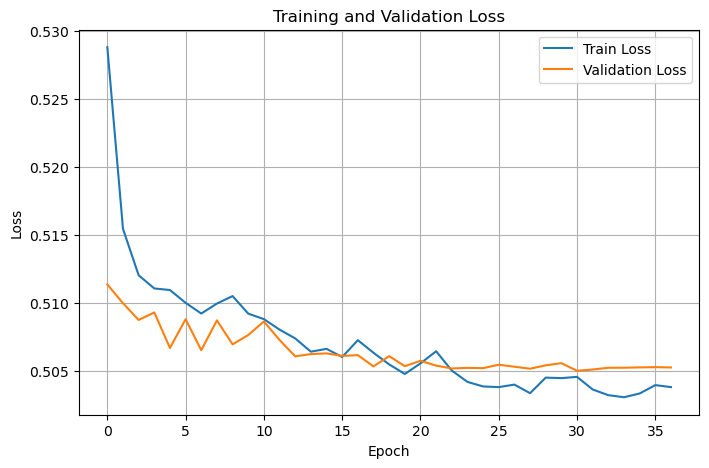

In [32]:
# =====================================
# 8. Plot Loss Curves
# =====================================
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [33]:
# =====================================
# 9. Evaluate on Test Set
# =====================================
model.load_state_dict(torch.load("best_model.pt"))
model.eval()

y_true, y_pred = evaluate(model, test_dl)

print("\nTest Accuracy:", (y_true == y_pred).mean())
print("\nClassification Report:\n", classification_report(y_true, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))

print("\nROC-AUC:", roc_auc_score(y_true, y_pred))


Test Accuracy: 0.7167034584253127

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.70      0.81     32750
           1       0.30      0.81      0.44      5302

    accuracy                           0.72     38052
   macro avg       0.63      0.75      0.63     38052
weighted avg       0.87      0.72      0.76     38052


Confusion Matrix:
 [[22996  9754]
 [ 1026  4276]]

ROC-AUC: 0.7543280283113676


In [34]:
# =====================================
# 8. Save & Load Model
# =====================================
#torch.save(model.state_dict(), "diabetes_model.pth")

# Later / for inference:
# model = DiabetesModel(input_dim)
# model.load_state_dict(torch.load("diabetes_model.pth"))
# model.eval()
